# TechMind — Entrenamiento del modelo

**Ciencia de Datos · Hackathon ONE (Alura + Oracle) · G9 LatAm**

TechMind organiza conocimiento técnico de forma automática. Este notebook entrena y
empaqueta el modelo que hace ese trabajo.

Dado un texto técnico —un artículo, un apunte, una página de documentación— el modelo
determina **a qué categoría pertenece**, **qué términos lo definen**, **en qué zona del
mapa temático cae** y **qué vector lo representa** para poder encontrar contenido
relacionado.

## Qué entra y qué sale

| | |
|---|---|
| **Entra** | `processed/*.jsonl` — el corpus ya limpio, que produce el notebook de EDA/ETL |
| **Sale** | `model/model.joblib` — los modelos entrenados, que carga el servicio de inferencia |
| **Sale** | `model/corpus_index.npz` — los vectores del corpus, que siembran la base de datos |

## Cómo está organizado

| Parte | Contenido |
|---|---|
| **A · Entrenamiento** | corpus → embeddings → clasificación → agrupamiento → mapa → palabras clave |
| **B · Uso** | el contrato del servicio, la búsqueda semántica y cómo crece la base de conocimiento |
| **C · Empaquetado** | serialización de los artefactos y publicación en OCI Object Storage |

## Las 8 categorías

Backend · Frontend · Móvil · Datos e IA · DevOps y Cloud · Bases de datos ·
Seguridad · Fundamentos

Cada contenido pertenece a **una sola**.

In [1]:
# Dependencias (Colab, CPU o GPU). Las versiones van fijadas para que dos personas
# que ejecuten este notebook obtengan exactamente los mismos números.
!pip -q install sentence-transformers==5.6.1 umap-learn==0.5.12 scikit-learn==1.9.0 joblib==1.5.3 matplotlib==3.11.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.7/596.7 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 35.2 MB/s eta 0:00:00


## Parte A — Entrenamiento

### 1. Imports

In [2]:
import json, pathlib
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, normalize
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sentence_transformers import SentenceTransformer
import umap
import joblib

### 2. Configuración

Todo lo ajustable vive aquí, en un solo sitio. Los parámetros que más cambian el
resultado son estos cuatro:

| Parámetro | Qué controla | Si lo subes | Si lo bajas |
|---|---|---|---|
| `CLASSIFIER_C` | cuánta libertad tiene el clasificador para ajustarse a los datos | se ajusta más al entrenamiento | generaliza más, pero puede quedarse corto |
| `SVD_COMPONENTS` | cuánta información del vocabulario literal recibe el clasificador | más señal, artefacto más grande | menos señal, más ligero. Con `0` se usa solo el embedding |
| `N_CLUSTERS` | en cuántos grupos temáticos se divide el corpus | agrupaciones más finas | agrupaciones más amplias |
| `TFIDF_MAX_FEATURES` | tamaño del vocabulario de los TF-IDF | vocabulario más rico, artefacto más pesado | más ligero, pierde términos poco frecuentes |

`SEED = 42` está fijado en cada división, modelo y proyección: **dos personas que
ejecuten este notebook obtienen exactamente los mismos números.**

In [3]:
SEED = 42

# Modelo de embeddings
# E5 multilingüe: sitúa "proteger una API con tokens" y "secure an API with tokens"
# en la misma región del espacio vectorial, que es lo que permite clasificar y buscar
# en español con un corpus mayoritariamente en inglés.
EMBEDDING_MODEL = "intfloat/multilingual-e5-small"
EMBEDDING_DIM   = 384
DOC_PREFIX      = "passage: "     # E5 distingue documentos...
QUERY_PREFIX    = "query: "       # ...de consultas, y hay que decírselo

# Las 8 categorías oficiales (un contenido pertenece a una sola).
CATEGORIES = ["Backend", "Frontend", "Móvil", "Datos e IA",
              "DevOps y Cloud", "Bases de datos", "Seguridad", "Fundamentos"]
VALID_LANGUAGES = {"es", "en"}

# --- Rutas ---
DATA_DIR  = pathlib.Path("processed")   # entrada: corpus del notebook de EDA/ETL
MODEL_DIR = pathlib.Path("model")       # salida: artefactos entrenados

TRAIN_PATH   = DATA_DIR / "train_corpus.jsonl"
TEST_EN_PATH = DATA_DIR / "test_corpus.jsonl"      # evaluación en inglés
TEST_ES_PATH = DATA_DIR / "test_corpus_es.jsonl"   # evaluación en español

MODEL_PATH  = MODEL_DIR / "model.joblib"
INDEX_PATH  = MODEL_DIR / "corpus_index.npz"
LATEST_PATH = MODEL_DIR / "latest.txt"

MODEL_VERSION = "v1"

# Parámetros ajustables
N_CLUSTERS    = 8      # grupos temáticos que descubre KMeans
N_KEYWORDS    = 6      # palabras clave por contenido
N_EXPLANATION = 5      # términos que justifican la categoría

# Regularización del clasificador (inversa de la fuerza). La sección 8 compara este
# valor contra uno más suelto en cada corrida, así que el efecto de cambiarlo se ve
# medido y no hay que suponerlo.
CLASSIFIER_C = 1.0

# Dimensiones de vocabulario que se suman al embedding para clasificar (sección 6).
# Poner 0 desactiva esa combinación y el clasificador trabaja solo con el embedding.
SVD_COMPONENTS = 500

# Documentos por lote al generar embeddings. 64 va bien en GPU T4; si aparece un
# error de memoria, bájalo a 32 o 16.
BATCH_SIZE = 64

# Vocabulario de los TF-IDF. Con min_df=1, cada errata del corpus se convierte en un
# término propio: el vocabulario se dispara y el artefacto engorda sin aportar señal.
TFIDF_MIN_DF       = 3
TFIDF_MAX_FEATURES = 50_000

# Conectores que se excluyen del vocabulario. Sin esta lista, "de", "con" o "the"
# aparecerían como palabras clave: son los tokens más frecuentes de cualquier texto,
# y el TF-IDF los recoge igual que a un término técnico.
# Van sin acentos porque los vectorizers usan strip_accents="unicode", así que "más"
# llega a la comparación ya convertido en "mas".
SPANISH_STOPWORDS = {
    "de", "la", "que", "el", "en", "y", "a", "los", "del", "se", "las", "por", "un",
    "para", "con", "no", "una", "su", "al", "es", "lo", "como", "mas", "o", "pero",
    "sus", "le", "ya", "este", "esta", "son", "entre", "cuando", "muy", "sin", "sobre",
    "ser", "tiene", "tambien", "hasta", "hay", "donde", "han", "quien", "estan", "cada",
    "porque", "puede", "pueden", "debe", "solo", "todo", "toda", "otro", "otra",
}
ENGLISH_STOPWORDS = {
    "the", "of", "and", "to", "in", "a", "is", "that", "it", "for", "on", "with", "as",
    "are", "this", "be", "by", "or", "an", "from", "at", "can", "you", "your", "we",
    "not", "have", "has", "but", "they", "their", "which", "will", "more", "than",
    "when", "what", "how", "its", "into", "only", "each", "one", "two", "them", "so",
}
STOPWORDS = SPANISH_STOPWORDS | ENGLISH_STOPWORDS

# Configuración compartida por los TF-IDF del notebook.
TFIDF_PARAMS = dict(
    ngram_range=(1, 2),
    min_df=TFIDF_MIN_DF,
    max_features=TFIDF_MAX_FEATURES,
    stop_words=sorted(STOPWORDS),
    strip_accents="unicode",
    sublinear_tf=True,
)

# Un color fijo por categoría, en el orden de CATEGORIES, para que una categoría se
# reconozca de un vistazo entre figuras distintas.
COLORS = plt.get_cmap("tab10").colors[:8]

### 3. Carpetas de trabajo

`processed/` guarda el corpus de entrada y `model/` los artefactos que produce este
notebook. Se crean si no existen, de modo que el notebook funcione en un Colab recién
abierto sin ningún paso manual.

In [5]:
for folder in (DATA_DIR, MODEL_DIR):
    existed = folder.exists()
    folder.mkdir(parents=True, exist_ok=True)
    print(f"  {str(folder) + '/':<14} {'ya existía' if existed else 'creada'}")

if not TRAIN_PATH.exists():
    print(f"\n⚠️  No se encuentra {TRAIN_PATH}")
    print("    Ejecuta antes el notebook de EDA/ETL (data/TechMind_01_EDA_ETL.ipynb),")
    print(f"    o sube los .jsonl del corpus a la carpeta '{DATA_DIR}/'.")

  processed/     ya existía
  model/         ya existía


### 4. Carga del corpus

El corpus llega **ya limpio** desde el notebook de EDA/ETL: aquí solo se carga y se
verifica que trae los campos que el resto del notebook espera.

Se cargan **tres conjuntos**, y la separación es deliberada:

- **Entrenamiento** — con lo que aprende el modelo.
- **Test en inglés** — mide la calidad del clasificador en el idioma mayoritario del corpus.
- **Test en español** — mide algo distinto: si lo aprendido **se transfiere a otro
  idioma**. Es la medida que importa para el producto, porque la interfaz es en español.

Ningún documento de test participa en el entrenamiento.

In [6]:
def load_corpus(path: pathlib.Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Falta {path}. Sube el corpus limpio a '{DATA_DIR}/'.")
    rows = [json.loads(line) for line in path.open(encoding="utf-8") if line.strip()]
    frame = pd.DataFrame(rows)
    missing = {"id", "title", "body", "category"} - set(frame.columns)
    if missing:
        raise ValueError(f"{path.name}: faltan columnas {sorted(missing)}")
    for optional in ("source", "url", "language"):
        if optional not in frame.columns:
            frame[optional] = None
    frame["language"] = frame["language"].fillna("es")
    return frame

train_df   = load_corpus(TRAIN_PATH)
test_es_df = load_corpus(TEST_ES_PATH)
# El conjunto en inglés es opcional: si no está, se evalúa solo en español.
test_en_df = load_corpus(TEST_EN_PATH) if TEST_EN_PATH.exists() else None
print(f"entrenamiento : {len(train_df)} documentos")
print(f"test español  : {len(test_es_df)} documentos")
print(f"test inglés   : {len(test_en_df) if test_en_df is not None else 0} documentos")

entrenamiento : 12800 documentos
test español  : 1279 documentos
test inglés   : 3200 documentos


### 5. Composición del corpus

Dos cosas que conviene ver antes de entrenar:

- **Cuántos documentos hay por categoría.** La métrica de evaluación (macro-F1) da el
  mismo peso a las ocho, así que una categoría con pocos ejemplos penaliza igual que
  una grande.
- **De qué fuente viene cada categoría.** Si una categoría procediera de una única
  fuente, el modelo podría estar aprendiendo el estilo de esa fuente en lugar del tema.

                documentos   es    en
category                             
Backend               1600  380  1220
Frontend              1600  412  1188
Móvil                 1600  374  1226
Datos e IA            1600  393  1207
DevOps y Cloud        1600  419  1181
Bases de datos        1600  333  1267
Seguridad             1600  188  1412
Fundamentos           1600  338  1262

Total: 12800 documentos  ·  22% español / 78% inglés

✅ el corpus cubre las 8 categorías oficiales


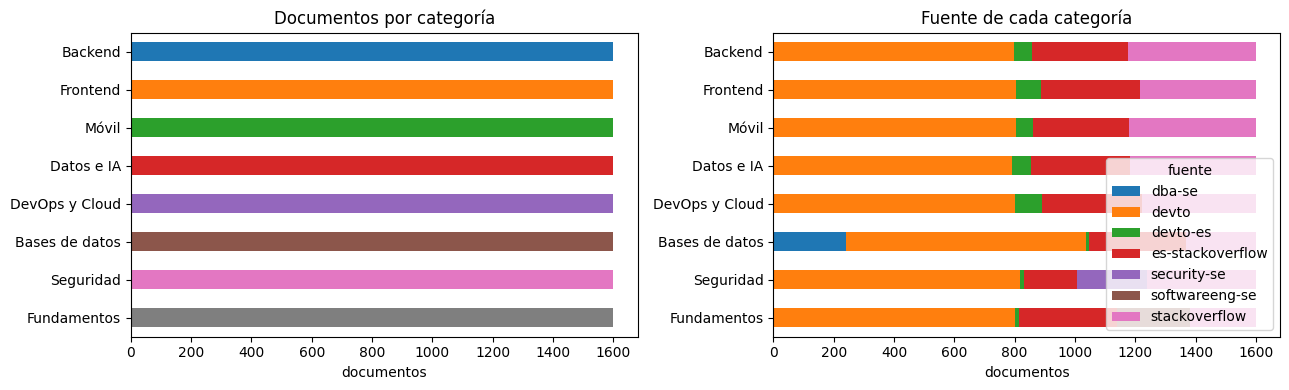

In [7]:
summary = (train_df.groupby("category")
           .agg(documentos=("id", "count"),
                es=("language", lambda s: (s == "es").sum()),
                en=("language", lambda s: (s == "en").sum()))
           .reindex(CATEGORIES).fillna(0).astype(int))
print(summary.to_string())
print(f"\nTotal: {len(train_df)} documentos"
      f"  ·  {train_df['language'].eq('es').mean():.0%} español"
      f" / {train_df['language'].eq('en').mean():.0%} inglés")

missing = set(CATEGORIES) - set(train_df["category"])
assert not missing, f"El corpus no cubre las 8 categorías. Faltan: {missing}"
print("\n✅ el corpus cubre las 8 categorías oficiales")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
summary["documentos"].plot(kind="barh", ax=ax1, color=COLORS)
ax1.set_title("Documentos por categoría"); ax1.set_xlabel("documentos"); ax1.set_ylabel("")
ax1.invert_yaxis()

if "source" in train_df.columns:
    (train_df.pivot_table(index="category", columns="source", values="id",
                          aggfunc="count", fill_value=0).reindex(CATEGORIES)
     .plot(kind="barh", stacked=True, ax=ax2))
    ax2.set_title("Fuente de cada categoría"); ax2.set_xlabel("documentos")
    ax2.set_ylabel(""); ax2.invert_yaxis()
    ax2.legend(title="fuente", loc="lower right")
else:
    ax2.axis("off")
plt.tight_layout(); plt.show()

### 6. Embeddings multilingües

Cada documento se convierte en un **vector de 384 números** que representa su
significado. Textos que hablan de lo mismo quedan cerca en ese espacio, **aunque estén
escritos en idiomas distintos**: es lo que permite que un modelo entrenado
mayoritariamente con textos en inglés clasifique contenido en español.

E5 distingue entre **documentos** (lo que se indexa) y **consultas** (lo que se busca),
y hay que indicárselo con un prefijo. Por eso hay dos funciones y no una: usar el
prefijo equivocado degrada los resultados de forma silenciosa, sin ningún error.

Los vectores salen **normalizados**, lo que hace que medir similitud entre dos textos
sea tan barato como un producto escalar.

In [8]:
# El dispositivo decide cuánto tarda esta sección: en GPU son 1-2 minutos para todo el
# corpus; en CPU puede irse a 30-60. Conviene saberlo antes de empezar a esperar.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
encoder = SentenceTransformer(EMBEDDING_MODEL, device=DEVICE)

print(f"dispositivo: {DEVICE}")
if DEVICE == "cpu":
    print("⚠️  Sin GPU. Embeber miles de documentos tardará bastante.")
    print("    En Colab: Entorno de ejecución → Cambiar tipo de entorno → GPU (T4)")

def _document(row) -> str:
    return f"{row['title']}. {row['body']}"

def embed_documents(texts, progress=None):
    """Vectoriza CONTENIDO, para indexarlo."""
    return encoder.encode([DOC_PREFIX + t for t in texts],
                          normalize_embeddings=True, batch_size=BATCH_SIZE,
                          show_progress_bar=len(texts) > 32 if progress is None else progress)

def embed_queries(texts, progress=None):
    """Vectoriza CONSULTAS, para buscar."""
    return encoder.encode([QUERY_PREFIX + t for t in texts],
                          normalize_embeddings=True, batch_size=BATCH_SIZE,
                          show_progress_bar=len(texts) > 32 if progress is None else progress)

train_docs   = [_document(r) for _, r in train_df.iterrows()]
test_es_docs = [_document(r) for _, r in test_es_df.iterrows()]

X_train   = embed_documents(train_docs)
X_test_es = embed_documents(test_es_docs)

if test_en_df is not None:
    test_en_docs = [_document(r) for _, r in test_en_df.iterrows()]
    X_test_en = embed_documents(test_en_docs)

print("embeddings de entrenamiento:", X_train.shape)

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/498k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  471MB            

...

dispositivo: cuda


Batches:   0%|          | 0/200 [00:00<?, ?it/s]

Batches:   0%|          | 0/20 [00:00<?, ?it/s]

Batches:   0%|          | 0/50 [00:00<?, ?it/s]

embeddings de entrenamiento: (12800, 384)


### 7. Clasificación

Se entrenan **dos modelos**, cada uno con un propósito:

- **El modelo de producción**, que es el que clasifica el contenido nuevo.
- **Un modelo explicable** (TF-IDF + regresión logística), que no clasifica en
  producción pero permite responder *"¿por qué esta categoría?"* señalando los términos
  concretos del texto que empujaron la decisión. Es lo que alimenta el campo
  `explanation` del contrato.

#### El clasificador combina dos representaciones

El modelo de producción no ve solo el embedding. Ve el **embedding concatenado con una
versión comprimida del vocabulario literal del texto**, porque las dos
representaciones fallan en sitios distintos y se compensan:

| | Qué capta bien | Qué se le escapa |
|---|---|---|
| **Embedding (E5)** | el significado, y a través de idiomas | los nombres propios técnicos, que difumina |
| **TF-IDF** | términos exactos: `Kubernetes`, `PostgreSQL`, `OAuth` | que "proteger una API" y "secure an API" son lo mismo |

El TF-IDF completo tendría decenas de miles de dimensiones, demasiadas para
concatenarlas. Se comprime con SVD a `SVD_COMPONENTS` dimensiones, que conservan lo
esencial en un espacio manejable.

Los dos bloques se normalizan a la misma escala antes de unirlos: si uno entrara con
valores mucho mayores que el otro, la regularización castigaría al pequeño y su
aportación se perdería.

> **Dos dimensiones distintas, y no son intercambiables.** El clasificador consume
> `384 + SVD_COMPONENTS` valores. Pero lo que se guarda en la base de datos y lo que
> viaja en el contrato es **siempre el embedding de 384**, porque es el espacio sobre
> el que la base resuelve la búsqueda por similitud.

In [9]:
label_encoder = LabelEncoder().fit(CATEGORIES)
y_train   = label_encoder.transform(train_df["category"])
y_test_es = label_encoder.transform(test_es_df["category"])
if test_en_df is not None:
    y_test_en = label_encoder.transform(test_en_df["category"])

# TF-IDF, ajustado únicamente con los datos de entrenamiento ---
# El vectorizador se entrena solo con el conjunto de entrenamiento para evitar
# que la información del conjunto de prueba influya en la evaluación del modelo.
baseline_vectorizer = TfidfVectorizer(**TFIDF_PARAMS)
Xtfidf_train = baseline_vectorizer.fit_transform(train_docs)
baseline_classifier = LogisticRegression(max_iter=1000, random_state=SEED).fit(Xtfidf_train, y_train)

# Los nombres de las características se obtienen una sola vez y luego se reutilizan
# cuando se generan las explicaciones del modelo, evitando cálculos innecesarios.
baseline_feature_names = np.array(baseline_vectorizer.get_feature_names_out())
print(f"modelo explicable entrenado (vocabulario: {len(baseline_vectorizer.vocabulary_)} términos)")

# Compresión del vocabulario
if SVD_COMPONENTS:
    svd = TruncatedSVD(n_components=SVD_COMPONENTS, random_state=SEED).fit(Xtfidf_train)

    # Se almacenan los componentes en precisión float32 para reducir el tamaño
    # del modelo sin afectar de forma apreciable los resultados obtenidos.
    # La conversión se realiza antes del entrenamiento para que el clasificador
    # utilice exactamente la misma representación durante entrenamiento e inferencia.
    svd.components_ = svd.components_.astype("float32")

    print(f"vocabulario comprimido a {SVD_COMPONENTS} dimensiones "
          f"({100 * svd.explained_variance_ratio_.sum():.1f} % de la varianza conservada, "
          f"{svd.components_.nbytes / 1e6:.0f} MB)")
else:
    svd = None
    print("compresión desactivada: el clasificador usa solo el embedding")

def build_features(embeddings, documents):
    """Construye lo que ve el CLASIFICADOR: embedding + vocabulario comprimido.

    No es lo que se guarda en la base de datos. El contrato expone siempre el
    embedding de 384 dimensiones, que es sobre el que corre la búsqueda.
    """
    if svd is None:
        return embeddings
    reduced = normalize(svd.transform(baseline_vectorizer.transform(documents)))
    return np.hstack([embeddings, reduced])

F_train   = build_features(X_train, train_docs)
F_test_es = build_features(X_test_es, test_es_docs)
if test_en_df is not None:
    F_test_en = build_features(X_test_en, test_en_docs)

#Modelo de producción
classifier = LogisticRegression(C=CLASSIFIER_C, class_weight="balanced",
                                max_iter=2000, random_state=SEED).fit(F_train, y_train)
print(f"clasificador entrenado con {len(F_train)} documentos "
      f"y {F_train.shape[1]} características por documento")

modelo explicable entrenado (vocabulario: 46092 términos)
vocabulario comprimido a 500 dimensiones (26.3 % de la varianza conservada, 92 MB)
clasificador entrenado con 12800 documentos y 884 características por documento


### 8. Evaluación

La métrica es **macro-F1**, no exactitud. La diferencia importa: la exactitud premia
acertar en las categorías grandes y puede ser alta aunque el modelo falle
sistemáticamente en las pequeñas. La macro-F1 da **el mismo peso a las ocho
categorías**, así que refleja si el modelo funciona para todas.

Se mide en dos escenarios, y la comparación entre ambos es informativa por sí sola:

- **Inglés** — el idioma mayoritario del entrenamiento. Mide la calidad del clasificador.
- **Español** — mide si lo aprendido **se transfiere** al idioma de la interfaz.

La tabla incluye también qué aporta cada pieza del diseño, para que las decisiones de
la sección anterior queden respaldadas por números en cada ejecución.

In [10]:
def macro_f1(model, X, y):
    return round(float(f1_score(y, model.predict(X), average="macro")), 4)

# Modelo de producción
embedding_macro_f1_es = macro_f1(classifier, F_test_es, y_test_es)
tfidf_macro_f1_es     = macro_f1(baseline_classifier,
                                 baseline_vectorizer.transform(test_es_docs), y_test_es)

if test_en_df is not None:
    embedding_macro_f1_en = macro_f1(classifier, F_test_en, y_test_en)
    tfidf_macro_f1_en     = macro_f1(baseline_classifier,
                                     baseline_vectorizer.transform(test_en_docs), y_test_en)
else:
    embedding_macro_f1_en = tfidf_macro_f1_en = None

# Comparación de diferentes configuraciones del modelo
# Se entrena una variante modificando un único componente a la vez
# para evaluar cuánto aporta cada decisión de diseño.
def _f1_pair(model, feats_en, feats_es):
    return (macro_f1(model, feats_en, y_test_en) if test_en_df is not None else None,
            macro_f1(model, feats_es, y_test_es))

# Se compara el valor actual de C con una regularización más flexible
# para comprobar si existe alguna mejora en el rendimiento.
CLASSIFIER_C_LOOSE = CLASSIFIER_C * 4
reference = LogisticRegression(C=CLASSIFIER_C_LOOSE, class_weight="balanced",
                               max_iter=2000, random_state=SEED).fit(F_train, y_train)
reference_macro_f1_en, reference_macro_f1_es = _f1_pair(
    reference, F_test_en if test_en_df is not None else None, F_test_es)

if svd is not None:

    # También se evalúa una versión del modelo utilizando únicamente
    # los embeddings, sin añadir las características del TF-IDF.
    plain = LogisticRegression(C=CLASSIFIER_C, class_weight="balanced", max_iter=2000,
                               random_state=SEED).fit(X_train, y_train)
    plain_macro_f1_en, plain_macro_f1_es = _f1_pair(
        plain, X_test_en if test_en_df is not None else None, X_test_es)
else:
    plain_macro_f1_en = plain_macro_f1_es = None

print(f"{'modelo':<38}{'inglés':>10}{'español':>10}")
print("-" * 58)
print(f"{f'producción ({F_train.shape[1]} caract., C={CLASSIFIER_C})':<38}"
      f"{str(embedding_macro_f1_en):>10}{embedding_macro_f1_es:>10}")
if plain_macro_f1_es is not None:
    print(f"{f'  sin vocabulario ({EMBEDDING_DIM} caract.)':<38}"
          f"{str(plain_macro_f1_en):>10}{plain_macro_f1_es:>10}")
print(f"{f'  con C={CLASSIFIER_C_LOOSE} (más suelta)':<38}"
      f"{str(reference_macro_f1_en):>10}{reference_macro_f1_es:>10}")
print(f"{'modelo explicable (TF-IDF)':<38}{str(tfidf_macro_f1_en):>10}{tfidf_macro_f1_es:>10}")

print(f"\naporta C={CLASSIFIER_C} frente a C={CLASSIFIER_C_LOOSE}: "
      f"{embedding_macro_f1_es - reference_macro_f1_es:+.4f} en español")
if plain_macro_f1_es is not None:
    print(f"aporta el vocabulario comprimido:   "
          f"{embedding_macro_f1_en - plain_macro_f1_en:+.4f} en inglés, "
          f"{embedding_macro_f1_es - plain_macro_f1_es:+.4f} en español")

print("\n--- Detalle por categoría (inglés) ---")
if test_en_df is not None:
    print(classification_report(y_test_en, classifier.predict(F_test_en),
                                labels=np.arange(len(CATEGORIES)),
                                target_names=label_encoder.classes_, zero_division=0))

print("--- Detalle por categoría (español) ---")
print(classification_report(y_test_es, classifier.predict(F_test_es),
                            labels=np.arange(len(CATEGORIES)),
                            target_names=label_encoder.classes_, zero_division=0))

modelo                                    inglés   español
----------------------------------------------------------
producción (884 caract., C=1.0)           0.7931    0.7697
  sin vocabulario (384 caract.)           0.7558    0.7244
  con C=4.0 (más suelta)                  0.7988    0.7737
modelo explicable (TF-IDF)                0.7986    0.7653

aporta C=1.0 frente a C=4.0: -0.0040 en español
aporta el vocabulario comprimido:   +0.0373 en inglés, +0.0453 en español

--- Detalle por categoría (inglés) ---
                precision    recall  f1-score   support

       Backend       0.71      0.65      0.68       400
Bases de datos       0.81      0.84      0.83       400
    Datos e IA       0.77      0.81      0.79       400
DevOps y Cloud       0.77      0.77      0.77       400
      Frontend       0.83      0.84      0.83       400
   Fundamentos       0.76      0.82      0.79       400
         Móvil       0.89      0.84      0.87       400
     Seguridad       0.82      0.7

8a. Matriz de confusión: a dónde van los errores
Una macro-F1 dice cuánto falla el modelo; la matriz de confusión dice en qué. No es lo mismo confundir Backend con Bases de datos —dos temas que se solapan de verdad, y donde hasta una persona dudaría— que confundirlo con Móvil, que indicaría un problema real.

Cada fila es la categoría verdadera y cada columna la que predijo el modelo: la diagonal son los aciertos.

In [ ]:
SHORT_NAMES = {c: c[:9] for c in label_encoder.classes_}

def show_confusion(y_true, y_pred, title: str):
    matrix = confusion_matrix(y_true, y_pred, labels=np.arange(len(CATEGORIES)))
    names = [SHORT_NAMES[c] for c in label_encoder.classes_]
    print(f"\n--- {title} ---")
    print(f"{'real|pred':<12}" + "".join(f"{n:>10}" for n in names))
    for i, name in enumerate(names):
        print(f"{name:<12}" + "".join(f"{v:>10}" for v in matrix[i]))

    errors = [(matrix[i, j], label_encoder.classes_[i], label_encoder.classes_[j])
               for i in range(len(CATEGORIES)) for j in range(len(CATEGORIES)) if i != j]
    errors.sort(reverse=True)
    print("  principales confusiones:")
    for n, actual, predicted in errors[:5]:
        support = int(matrix[list(label_encoder.classes_).index(actual)].sum())
        print(f"    {actual} -> {predicted}: {n} docs ({100 * n / support:.1f}% de {actual})")

if test_en_df is not None:
    show_confusion(y_test_en, classifier.predict(F_test_en), "inglés")
show_confusion(y_test_es, classifier.predict(F_test_es), "español")